Matrix Multiplication Runtime Comparison
Matrix #  Size      Naive Time (s)      NumPy Time (s)      
1         3x3     0.000019            0.000022            
2         6x6     0.000059            0.000010            
3         12x12    0.000396            0.000023            
4         24x24    0.002699            0.000036            
5         48x48    0.018750            0.000038            
6         96x96    0.150565            0.000281            
7         192x192   1.183854            0.000686            
8         384x384   10.935230           0.003900            


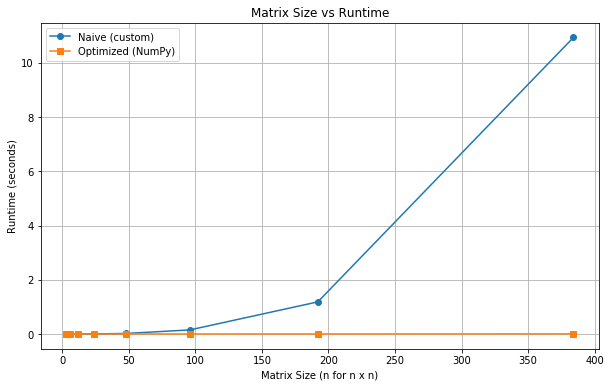

In [14]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import time

#matrix multiplication
def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]

    return C

#build 8 matrix sizes
sizes = []
n = 3
for _ in range(8):
    sizes.append(n)
    n *= 2

matrix_numbers = list(range(1, 9))
naive_times = []
numpy_times = []

print("Matrix Multiplication Runtime Comparison")
print(f"{'Matrix #':<10}{'Size':<10}{'Naive Time (s)':<20}{'NumPy Time (s)':<20}")

for i, size in enumerate(sizes, start=1):
    #random matrices
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    A_list = A_np.tolist()
    B_list = B_np.tolist()

    #time naive multiplication
    start_naive = time.perf_counter()
    naive_matrix_multiplication(A_list, B_list)
    end_naive = time.perf_counter()
    naive_time = end_naive - start_naive
    naive_times.append(naive_time)

    #time NumPy multiplication
    start_numpy = time.perf_counter()
    np.dot(A_np, B_np)
    end_numpy = time.perf_counter()
    numpy_time = end_numpy - start_numpy
    numpy_times.append(numpy_time)

    print(f"{i:<10}{size}x{size:<6}{naive_time:<20.6f}{numpy_time:<20.6f}")

#plot runtimes
plt.figure(figsize=(10, 6))
plt.plot(sizes, naive_times, marker='o', label='Naive (custom)')
plt.plot(sizes, numpy_times, marker='s', label='Optimized (NumPy)')
plt.title("Matrix Size vs Runtime")
plt.xlabel("Matrix Size (n for n x n)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.legend()
plt.show()